## Sigmoid Function:
* Sigmoid is a mathematical function that maps any real-valued number into a value between 0 and 1.
* Its characteristic "S"-shaped curve makes it particularly useful in scenarios where we need to convert outputs into probabilities.
* This function is often called the logistic function.

### Mathematically, sigmoid is represented as:
#### **σ= 1/1+exp(-z)**



**Unlike Linear Regression, which can predict any number from negative to positive infinity,
Logistic Regression uses the Sigmoid Function to "squish" the output into a range
between 0 and 1. If the output is > 0.5, we classify it as "Class 1"; otherwise, it's "Class 0."**

### Logistic Regression:
_Logistic Regression is a supervised machine learning algorithm used for classification problems. Unlike linear regression, which predicts continuous values it predicts the probability that an input belongs to a specific class._

* It is used for binary classification where the output can be one of two possible categories such as Yes/No, True/False or 0/1.
* It uses sigmoid function to convert inputs into a probability value between 0 and 1.

### Types of Logistic Regression:



#### Binomial Logistic Regression:
* This type is used when the dependent variable has only two possible categories.

* Examples include Yes/No, Pass/Fail or 0/1. It is the most common form of logistic regression and is used for binary classification problems.

##### **We will be using Scikit-learn library for this and shows how to use the breast cancer dataset to implement a Logistic Regression model for classification.**

In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_testb = train_test_split(X, y, test_size=0.20, random_state=23)

clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)
y_predb=clf.predict(X_test)

acc = accuracy_score(y_testb, clf.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 96.49%


##### This code uses logistic regression to classify whether a sample from the breast cancer dataset is malignant or benign.

#### Multinomial Logistic Regression:
* Target variable can have 3 or more possible types which are not ordered i.e types have no quantitative significance like “disease A” vs “disease B” vs “disease C”.

**Example:**
* Digit recognition → (0–9 classes)
* Sentiment → Positive / Neutral / Negative
* Iris dataset → Setosa / Versicolor / Virginica

#### **In this case, the softmax function is used in place of the sigmoid function. **Softmax function** for K classes will be:**

### **Softmax(Zi) =exp(Zi)/∑exp(Zj)**

Below is an example of implementing multinomial logistic regression using the Digits dataset from scikit-learn:



In [21]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load Data
data = load_iris()

X_train, X_test, y_train, y_test= train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 2. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model (IMPORTANT PARAMETER)
model = LogisticRegression( solver='lbfgs', max_iter=200)
model.fit(X_train_scaled, y_train)

# 4. Prediction
y_pred = model.predict(X_test_scaled)

# 5. Accuracy
print("Accuracy:", accuracy_score(y_testb, y_predb))

Accuracy: 1.0


In [22]:
probs = model.predict_proba(X_test_scaled)
print(probs[:3])

[[1.14571961e-02 8.75978526e-01 1.12564278e-01]
 [9.64411302e-01 3.55882864e-02 4.11287569e-07]
 [3.77322994e-08 2.88231142e-03 9.97117651e-01]]


### Row 1:
* Class 0 → 1.1%
* Class 1 → 87.6% (highest)
* Class 2 → 11.3%

### Prediction = Class 1


#### Row 2:

[0.964, 0.035, 0.0000004]
* Class 0 → 96.4% (Highest)
* Class 1 → 3.5%
* Class 2 → ~0%

##### Prediction = Class 0

* The predict_proba() function returns the probability of each class for a given input.
* Each row represents one sample, and each column represents a class. The class with the highest probability is selected as the final prediction.
* The probabilities in each row sum to 1 due to the Softmax function used in multinomial logistic regression.

## How to Evaluate Logistic Regression Model?




* Evaluating the logistic regression model helps assess its performance and ensure it generalizes well to new, unseen data.
* The following metrics are commonly used:
1. Accuracy
2. Precision
3. Recall
4. F1 Score

#### Understanding the Confusion Matrix:
Confusion matrix is a simple table used to measure how well a classification model is performing.

It compares the predictions made by the model with the actual results and shows where the model was right orwrong.

This helps you understand where the model is making mistakes so you can improve it. It breaks down the predictions into four categories:

* **True Positive (TP):** The model correctly predicted a positive outcome i.e the actual outcome was positive.
* **True Negative (TN):** The model correctly predicted a negative outcome i.e the actual outcome was negative.
* **False Positive (FP):** The model incorrectly predicted a positive outcome i.e the actual outcome was negative. It is also known as a Type I error.
* **False Negative (FN):** The model incorrectly predicted a negative outcome i.e the actual outcome was positive. It is also known as a Type II error.


### 1. Accuracy:
Accuracy provides the proportion of correctly classified instances.

##### **Accuracy = (TP + TN)/(TP+TN+FP+FN)**


### 2. Precision:
Precision focuses on the accuracy of positive predictions.

#### **Precision=TP/ TP +FP**



### 3. Recall :
(Sensitivity or True Positive Rate): Recall measures the proportion of correctly predicted positive instances among all actual positive instances.

#### Recall=TP/TP+FN



### 4. F1 Score:
F1 score is the harmonic mean of precision and recall

#### F1 Score = 2 * Precison * Recall/(Precision+Recall)


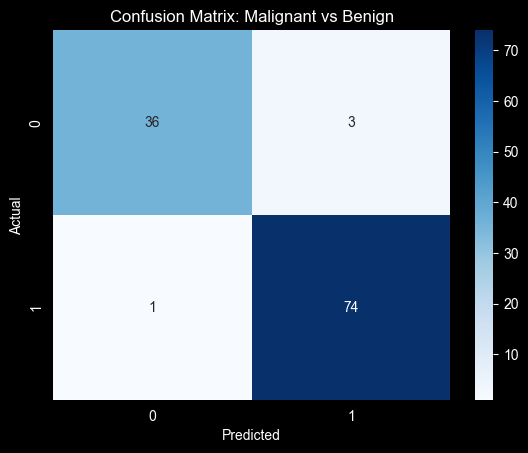

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_testb,y_predb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Malignant vs Benign')
plt.show()

#### Reflection:
* A False Negative(3) occurs when the model predicts that a patient is healthy when they actually have cancer. This can delay diagnosis and treatment, allowing the disease to progress to a more severe or even fatal stage.
* On the other hand, a False Positive(1) means predicting cancer in a healthy patient. While this may cause stress and require additional medical tests, it does not pose an immediate threat to life.
* Therefore, minimizing False Negatives is critical in healthcare applications, even if it leads to a slight increase in False Positives.

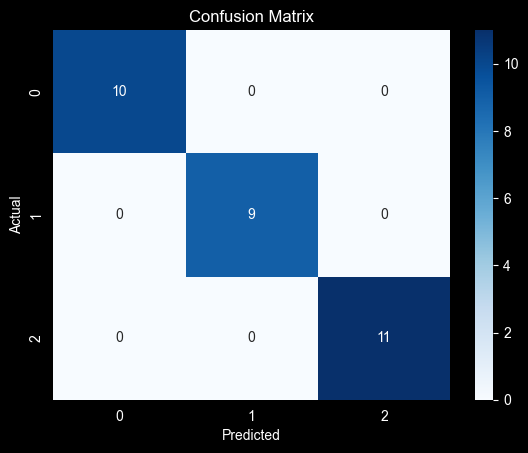

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm= confusion_matrix(y_test, y_pred)

# Plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

* All values are present on the diagonal, indicating correct predictions for every class.
* There are no off-diagonal values, meaning zero misclassifications.
* The model achieved 100% accuracy (30 correct out of 30 total samples).
* No False Positives (FP) and No False Negatives (FN) were observed.
* Each class is predicted perfectly:

Class 0 → 10/10 correct

Class 1 → 9/9 correct

Class 2 → 11/11 correct

* The model has perfect precision, recall, and F1-score (1.0) for all classes.
* The classifier shows excellent separation between all classes.

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



* A confusion matrix shows how many predictions were correct and incorrect for each class.
* It helps identify specific types of errors.
* Evaluation metrics like precision, recall, and F1-score provide deeper insights into model performance beyond accuracy, especially in imbalanced datasets.

### Probability Check using predict_proba()

In [33]:
probs = model.predict_proba(X_test_scaled)

# Display first 5 probability predictions
print(probs[:5])

[[1.14571961e-02 8.75978526e-01 1.12564278e-01]
 [9.64411302e-01 3.55882864e-02 4.11287569e-07]
 [3.77322994e-08 2.88231142e-03 9.97117651e-01]
 [1.32093187e-02 7.59399159e-01 2.27391523e-01]
 [1.88856076e-03 7.52135755e-01 2.45975684e-01]]



#### Observation:

* The predict_proba() function returns the probability of each class for every input sample.
* Each row represents one data point, and each column represents the probability of belonging to a particular class.
* The sum of probabilities in each row is always equal to 1.
* The class with the highest probability is selected as the final prediction by the model.